# Thesis Figure 5 â€” Perturbation / Region Occlusion

Illustrates the **region occlusion** concept from the perturbation-based objective function.

For three replacement strategies (ImageNet mean, Gaussian blur, interlacing), produces:
1. **Replacement image** $I_{rep}$ â€” the 224Ã—224 baseline used to fill the occluded region.
2. **Original + region outline** â€” the input image with region $R$ drawn with a contrasting border.
3. **Occluded image** $I_R$ â€” the original with region $R$ replaced by $I_{rep}$.

Edit only the **Configuration** cell.

In [2]:
# â”€â”€ Configuration â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
IMAGE_PATH = r"REPO_ROOT/images\images\imagenets_0082.jpg"

SEG_OVERRIDES = [
    "segmentation=hexagonal",
    "segmentation.hex_radius=4",
]

# Segment IDs that form region R (highlighted / replaced region).
# Set to None to auto-pick via random walk of REGION_SIZE steps from image centre.
REGION_IDS: list | None = None
REGION_SIZE = 30  # used only when REGION_IDS is None
RANDOM_SEED = 44  # for reproducibility

SOLID_COLOR = (0, 0, 0)  # RGB in [0, 255]; default black

OUTLINE_COLOR = "red"  # boundary outline colour
OUTLINE_WIDTH = 2.5  # boundary outline line width

OUTPUT_DIR = "output"

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from hydra.utils import instantiate


REPO_ROOT = Path("../..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from ciao.data.preprocessing import load_and_preprocess_image
from ciao.data.replacement import (
    imagenet_mean_replacement,
    interlacing_replacement,
    make_blur_replacement,
    make_mean_color_replacement,
    make_solid_color_replacement,
)
from ciao.visualization.visualization import _to_hwc


OUT = Path(OUTPUT_DIR)
OUT.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}  |  repo: {REPO_ROOT}")

device: cpu  |  repo: REPO_ROOT/n

In [4]:
# â”€â”€ Load image and build segmentation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=str(REPO_ROOT / "configs"), version_base=None):
    cfg = compose(
        config_name="base",
        overrides=SEG_OVERRIDES + ["replacement=imagenet_mean"],
    )

img_tensor = load_and_preprocess_image(IMAGE_PATH, device=device)  # [C, H, W]
input_batch = img_tensor.unsqueeze(0)  # [1, C, H, W]

segmentation_fn = instantiate(cfg.segmentation)
image_graph = segmentation_fn(img_tensor)

img_np = _to_hwc(input_batch)  # [H, W, 3] float32 in [0, 1]
segs = image_graph.segments.cpu().numpy()  # [H, W] int32

print(f"Image shape : {img_np.shape}")
print(f"Segments    : {image_graph.num_segments} unique IDs")

Image shape : (224, 224, 3)
Segments    : 1273 unique IDs


In [5]:
# â”€â”€ Choose region R â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import random


if REGION_IDS is not None:
    region = list(REGION_IDS)
else:
    # Random walk: at each step move to a random unvisited neighbour of the
    # current position. Falls back to backtracking if stuck, so it always
    # reaches REGION_SIZE segments. Produces an irregular, non-symmetric shape.
    rng = random.Random(RANDOM_SEED)
    cy, cx = img_np.shape[0] // 3, img_np.shape[1] // 3
    current = int(segs[cy, cx])
    visited = [current]
    stack = [current]
    while len(visited) < REGION_SIZE and stack:
        neighbours = [nb for nb in image_graph.adj_list[stack[-1]] if nb not in visited]
        if neighbours:
            nxt = rng.choice(neighbours)
            visited.append(nxt)
            stack.append(nxt)
        else:
            stack.pop()  # backtrack if dead end
    region = visited

region_mask = np.zeros(segs.shape, dtype=np.float32)
for sid in region:
    region_mask[segs == sid] = 1.0

print(f"Region R    : {region}")
print(f"Pixels      : {int(region_mask.sum())} / {region_mask.size}")

Region R    : [563, 601, 639, 638, 675, 676, 713, 714, 715, 752, 789, 788, 751, 750, 787, 824, 862, 825, 863, 826, 827, 790, 753, 791, 828, 829, 867, 866, 904, 903]
Pixels      : 1251 / 50176


In [6]:
# â”€â”€ Build replacement images for all strategies â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
blur_fn = make_blur_replacement()
mean_color_fn = make_mean_color_replacement()
solid_color_fn = make_solid_color_replacement(color=SOLID_COLOR)

STRATEGIES = [
    ("imagenet_mean", "ImageNet Mean", imagenet_mean_replacement(img_tensor)),
    ("mean_color", "Mean Color", mean_color_fn(img_tensor)),
    ("blur", "Gaussian Blur", blur_fn(img_tensor)),
    ("interlacing", "Interlacing", interlacing_replacement(img_tensor)),
    ("solid_color", "Solid Color", solid_color_fn(img_tensor)),
]

# Convert all replacement tensors to displayable numpy arrays
strategies_np = [
    (key, label, _to_hwc(i_rep.unsqueeze(0))) for key, label, i_rep in STRATEGIES
]

# Pre-compute the region mask as a torch tensor for occlusion
mask_t = torch.tensor(region_mask, device=device).unsqueeze(0)  # [1, H, W]

print("Replacement images built.")

Replacement images built.


In [7]:
# â”€â”€ Shared helpers â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def occlude(img_t: torch.Tensor, i_rep_t: torch.Tensor) -> np.ndarray:
    """Apply mask to produce I_R = (1 - M)*I + M*I_rep, returned as HWC numpy."""
    occluded = (1.0 - mask_t) * img_t + mask_t * i_rep_t
    return _to_hwc(occluded.unsqueeze(0))


def save(fig: plt.Figure, stem: str) -> None:
    fig.savefig(OUT / f"{stem}.png", dpi=150, bbox_inches="tight")
    fig.savefig(OUT / f"{stem}.pdf", dpi=150, bbox_inches="tight")
    print(f"Saved â†’ {OUT / stem}.png")


def plot_single(image: np.ndarray, title: str | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(image)
    if title:
        ax.set_title(title, fontsize=11)
    ax.axis("off")
    fig.tight_layout(pad=0)
    return fig


print("Helpers ready.")

Helpers ready.


Saved â†’ output\perturbation_replacement_imagenet_mean.png


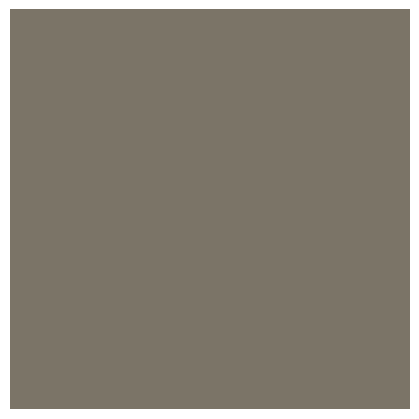

Saved â†’ output\perturbation_replacement_mean_color.png


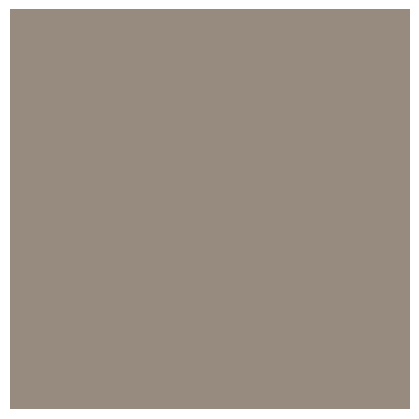

Saved â†’ output\perturbation_replacement_blur.png


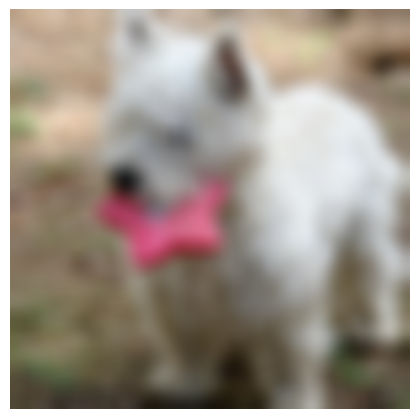

Saved â†’ output\perturbation_replacement_interlacing.png


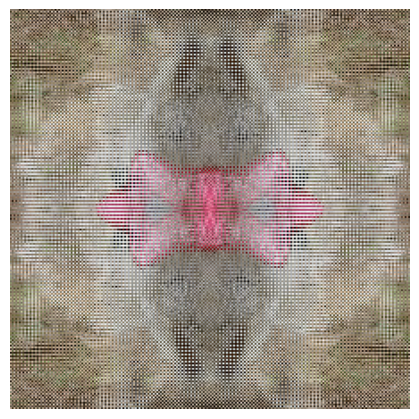

Saved â†’ output\perturbation_replacement_solid_color.png


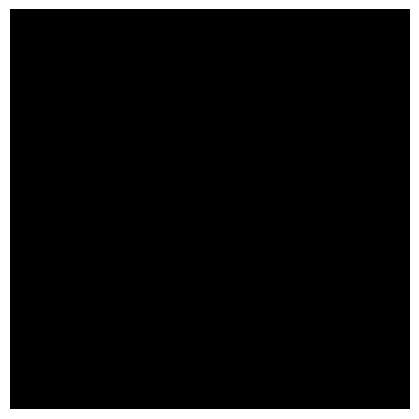

In [8]:
# â”€â”€ Figure: replacement images (one per strategy) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
for key, label, i_rep_np in strategies_np:
    fig = plot_single(i_rep_np)
    save(fig, f"perturbation_replacement_{key}")
    plt.show()

Saved â†’ output\perturbation_original_outlined.png


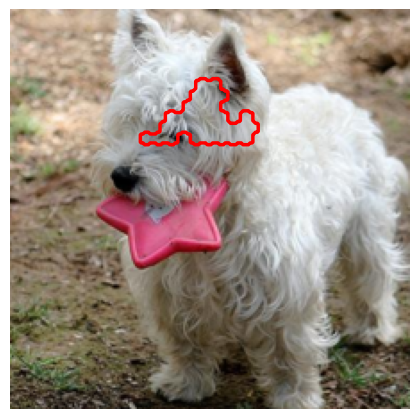

In [9]:
# â”€â”€ Figure: original image with region R outlined â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# The outlined image is strategy-independent â€” saved once.
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(img_np)
ax.contour(
    region_mask,
    levels=[0.5],
    colors=[OUTLINE_COLOR],
    linewidths=[OUTLINE_WIDTH],
)
ax.axis("off")
fig.tight_layout(pad=0)
save(fig, "perturbation_original_outlined")
plt.show()

Saved â†’ output\perturbation_occluded_imagenet_mean.png


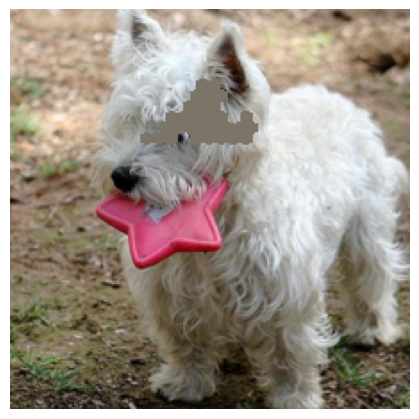

Saved â†’ output\perturbation_occluded_mean_color.png


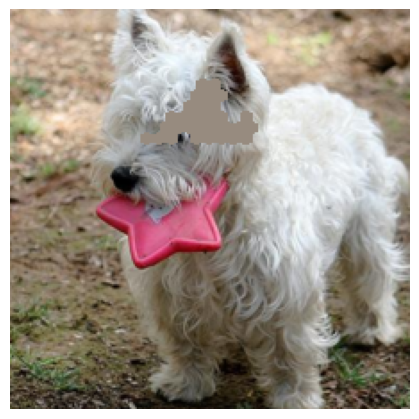

Saved â†’ output\perturbation_occluded_blur.png


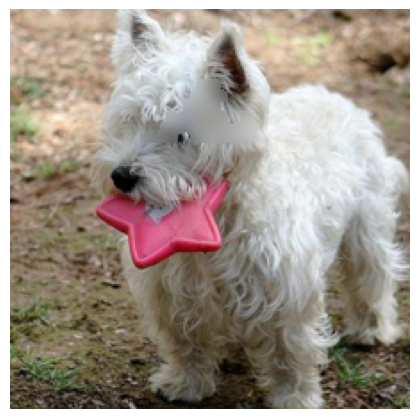

Saved â†’ output\perturbation_occluded_interlacing.png


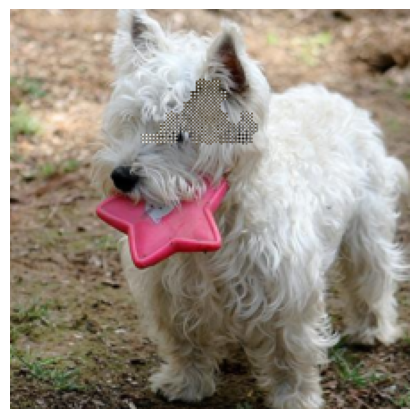

Saved â†’ output\perturbation_occluded_solid_color.png


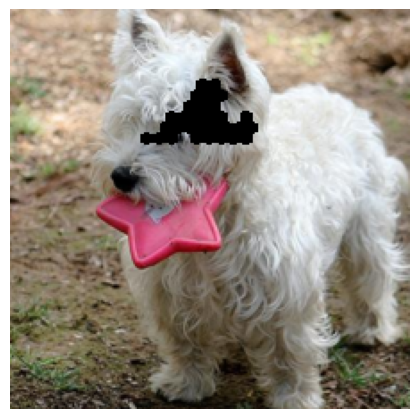

In [10]:
# â”€â”€ Figure: occluded images (one per strategy) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
for (key, label, i_rep_t), (_, _, i_rep_np) in zip(
    STRATEGIES, strategies_np, strict=False
):
    i_r_np = occlude(img_tensor, i_rep_t)
    fig = plot_single(i_r_np)
    save(fig, f"perturbation_occluded_{key}")
    plt.show()

Saved â†’ output\perturbation_composite.png


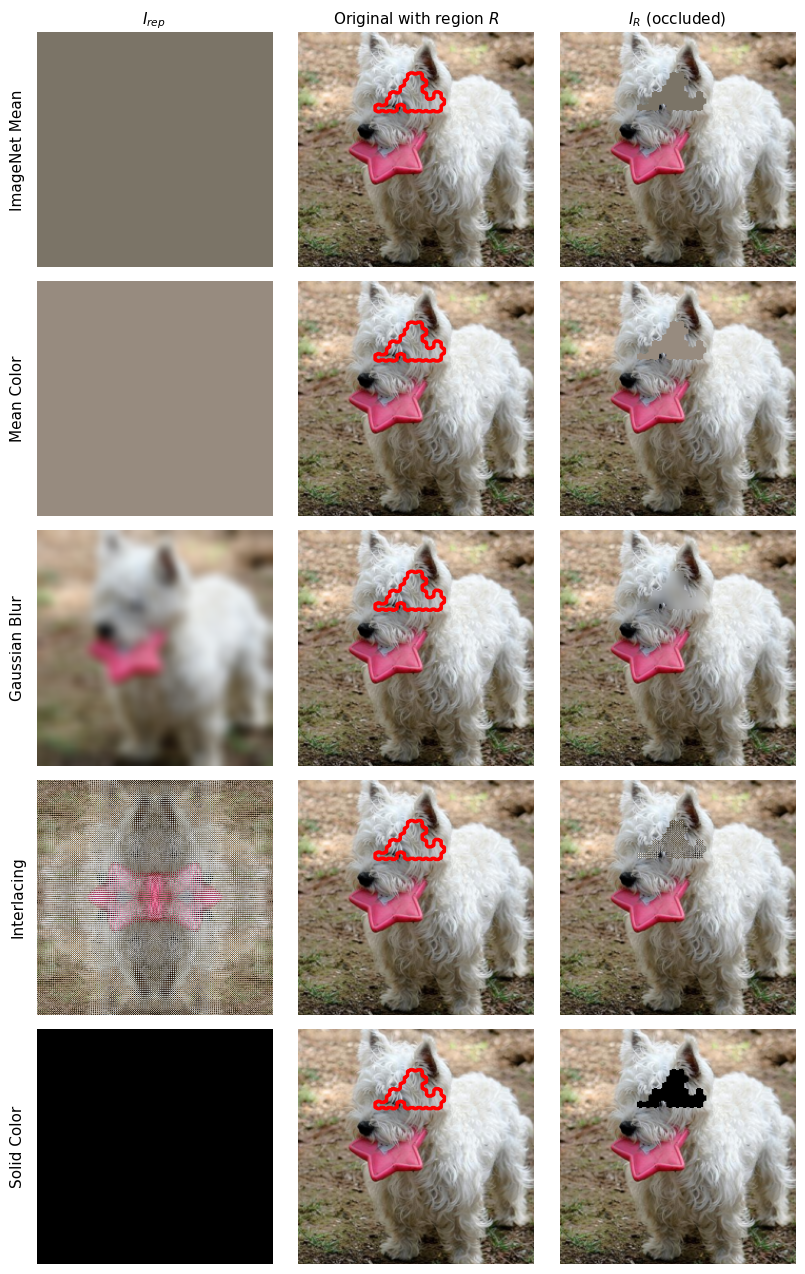

In [11]:
# â”€â”€ Composite figure: 5 rows Ã— 3 columns â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
#   rows    : ImageNet mean | Mean Color | Gaussian blur | Interlacing | Solid Color
#   columns : I_rep  |  original + outline  |  I_R

COL_TITLES = [r"$I_{rep}$", r"Original with region $R$", r"$I_R$ (occluded)"]

fig, axes = plt.subplots(
    5,
    3,
    figsize=(10, 16),
    gridspec_kw={"hspace": 0.06, "wspace": 0.04},
)

for row, ((key, label, i_rep_t), (_, _, i_rep_np)) in enumerate(
    zip(STRATEGIES, strategies_np, strict=False)
):
    i_r_np = occlude(img_tensor, i_rep_t)

    # Column 0: replacement image
    axes[row, 0].imshow(i_rep_np)

    # Column 1: original + region outline
    axes[row, 1].imshow(img_np)
    axes[row, 1].contour(
        region_mask,
        levels=[0.5],
        colors=[OUTLINE_COLOR],
        linewidths=[OUTLINE_WIDTH],
    )

    # Column 2: occluded image
    axes[row, 2].imshow(i_r_np)

    # Row label placed outside the left edge (survives axis("off"))
    axes[row, 0].text(
        -0.05,
        0.5,
        label,
        transform=axes[row, 0].transAxes,
        fontsize=11,
        va="center",
        ha="right",
        rotation=90,
    )

for col, title in enumerate(COL_TITLES):
    axes[0, col].set_title(title, fontsize=11, pad=6)

for ax in axes.flat:
    ax.axis("off")
    ax.set_aspect("equal")

save(fig, "perturbation_composite")
plt.show()